# Task-2: Predictive Analysis Using Machine Learning

This notebook demonstrates a predictive analysis workflow using NYC Yellow Taxi trip data. It includes library installation, data loading, data processing, visualization, model training, and exporting results.

## 1. Install and Import Libraries

The first step installs required packages and imports libraries such as pandas, NumPy, matplotlib, scikit-learn, and dask.

In [2]:
# Install required packages (uncomment if needed)
 #pip install pandas numpy matplotlib scikit-learn dask requests pyarrow


import os
import tempfile
from urllib.parse import urlparse

import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report,
                             f1_score, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load or Generate Sample Data

This section loads a sample of the taxi dataset from a remote Parquet file. If direct remote loading fails, the notebook downloads the file locally and reads it with pandas.

In [3]:
DEFAULT_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"


def download_remote_file(url: str) -> str:
    parsed = urlparse(url)
    suffix = os.path.splitext(parsed.path)[1] or ".parquet"
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
    temp_file.close()

    with requests.get(url, stream=True) as response:
        response.raise_for_status()
        with open(temp_file.name, "wb") as out_file:
            for chunk in response.iter_content(chunk_size=16_384):
                if chunk:
                    out_file.write(chunk)

    return temp_file.name


def load_sample_data(input_path: str, sample_size: int = 1000) -> pd.DataFrame:
    parsed = urlparse(input_path)
    if parsed.scheme in {"http", "https"}:
        try:
            df = dd.read_parquet(input_path).head(sample_size, compute=True)
            return df
        except Exception as exc:
            print("Remote read failed, downloading locally:", exc)
            local_path = download_remote_file(input_path)
            df = pd.read_parquet(local_path)
            return df.sample(n=min(sample_size, len(df)), random_state=42)

    df = pd.read_parquet(input_path)
    return df.sample(n=min(sample_size, len(df)), random_state=42)


sample_df = load_sample_data(DEFAULT_URL, sample_size=1000)
print(f"Loaded sample dataframe with {len(sample_df)} rows.")
sample_df.head()

Loaded sample dataframe with 1000 rows.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


## 3. Process Data

Clean the dataset, engineer new features, and prepare the data for modeling.

In [4]:
def process_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df = df[df["tpep_pickup_datetime"].notna()]
    df = df[df["fare_amount"] > 0]
    df = df[df["trip_distance"] >= 0]
    df = df[df["passenger_count"] > 0]

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["tip_rate"] = df["tip_amount"] / df["fare_amount"]
    df["high_tip"] = (df["tip_rate"] >= 0.25).astype(int)

    return df

processed_df = process_data(sample_df)
print(f"Processed dataset with {len(processed_df)} rows.")
processed_df[["pickup_hour", "pickup_dayofweek", "tip_rate", "high_tip"]].head()

Processed dataset with 981 rows.


,pickup_hour,pickup_dayofweek,tip_rate,high_tip
0,0,6,0.000000,0
1,0,6,0.506329,1
2,0,6,1.006711,1
4,0,6,0.287719,1
5,0,6,0.781250,1


## 4. Visualize Data

Create charts to show the distribution of tip rates and the frequency of high-tip rides.

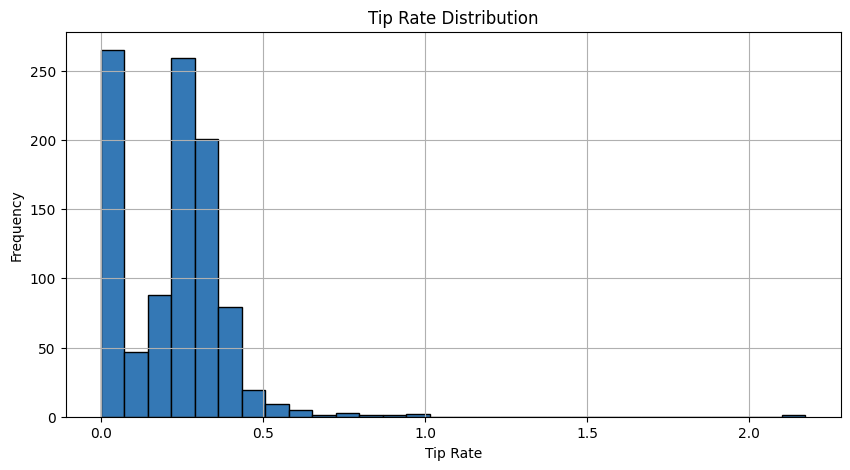

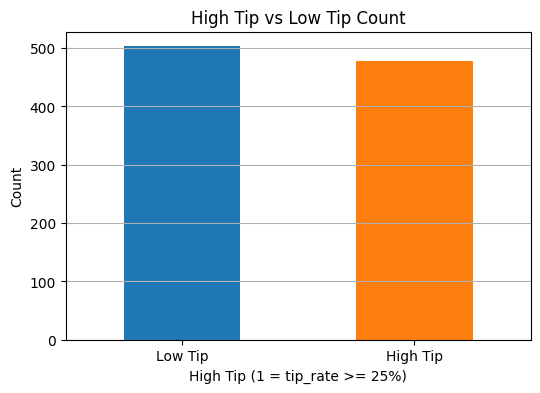

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(processed_df["tip_rate"].fillna(0), bins=30, color="#3478b5", edgecolor="black")
plt.title("Tip Rate Distribution")
plt.xlabel("Tip Rate")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
processed_df["high_tip"].value_counts().sort_index().plot(
    kind="bar", color=["#1f77b4", "#ff7f0e"]
)
plt.title("High Tip vs Low Tip Count")
plt.xlabel("High Tip (1 = tip_rate >= 25%)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Low Tip", "High Tip"], rotation=0)
plt.grid(axis="y")
plt.show()

## 5. Export Notebook Results

Save the processed sample dataset to disk and export the visualizations if needed.

In [8]:
output_csv = "processed_taxi_sample.csv"
processed_df.to_csv(output_csv, index=False)
print(f"Processed sample saved to {output_csv}")

fig_path = "tip_analysis.png"
plt.figure(figsize=(10, 5))
plt.hist(processed_df["tip_rate"].fillna(0), bins=30, color="#3478b5", edgecolor="black")
plt.title("Tip Rate Distribution")
plt.xlabel("Tip Rate")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(fig_path)
plt.close()
print(f"Visualization saved to {fig_path}")

Processed sample saved to processed_taxi_sample.csv
Visualization saved to tip_analysis.png
